## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


## 2. Load & Aggregate Data

Source files (`train.csv`, `features.csv`) are the standard Kaggle competition files:
- `train.csv`: `Store, Dept, Date, Weekly_Sales, IsHoliday` - 421,570 rows
- `features.csv`: `Store, Date, Temperature, Fuel_Price, CPI, Unemployment, ...` - store-level weekly exogenous data

We sum `Weekly_Sales` across **all 45 stores and departments** to get one national weekly total, average the exogenous features across stores, then resample both to **calendar months**.


In [2]:
import pandas as pd

train = pd.read_csv(
    "https://raw.githubusercontent.com/vicky60629/Walmart-Store-Sales-Forecasting/master/data/train.csv",
    parse_dates=['Date'])
features = pd.read_csv(
    "https://raw.githubusercontent.com/vicky60629/Walmart-Store-Sales-Forecasting/master/data/features.csv",
    parse_dates=['Date'])

# Total weekly sales across all stores & departments
weekly_total = train.groupby('Date', as_index=False)['Weekly_Sales'].sum().set_index('Date')

# National-average weekly exogenous features
weekly_exog = features.groupby('Date', as_index=False)[
    ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].mean().set_index('Date')

weekly = weekly_total.join(weekly_exog, how='left')

# Aggregate weekly -> monthly
monthly_sales = weekly['Weekly_Sales'].resample('MS').sum()
monthly_exog = weekly[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].resample('MS').mean()
week_counts = weekly['Weekly_Sales'].resample('MS').count()

monthly = pd.concat([monthly_sales, monthly_exog], axis=1)
monthly.columns = ['Total_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
monthly = monthly[week_counts >= 4]
monthly.index.name = 'Month'
monthly.index.freq = 'MS'

print(f"Monthly series shape: {monthly.shape}")
print(f"Date range: {monthly.index.min().date()} to {monthly.index.max().date()}")
monthly.head()

Monthly series shape: (33, 5)
Date range: 2010-02-01 to 2012-10-01


,Total_Sales,Temperature,Fuel_Price,CPI,Unemployment
Month,,,,,
2010-02-01,"190,332,983.040",36.288,2.692,167.834,8.619
2010-03-01,"181,919,802.500",47.194,2.787,167.931,8.619
2010-04-01,"231,412,368.050",56.901,2.869,167.678,8.498
2010-05-01,"186,710,934.340",65.364,2.917,167.642,8.498
2010-06-01,"192,246,172.360",75.077,2.788,168.005,8.498


## 3. The Time Series Object & Plot

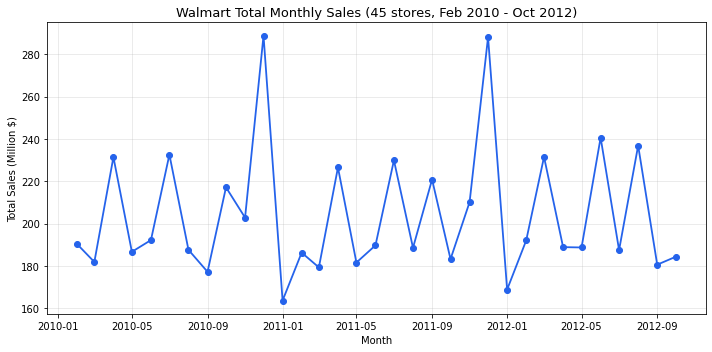

In [3]:
ts = monthly['Total_Sales']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.index, ts.values / 1e6, marker='o', color='#2563eb', linewidth=1.8)
ax.set_title('Walmart Total Monthly Sales (45 stores, Feb 2010 - Oct 2012)', fontsize=13)
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales (Million $)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.1 Trend
The data shows a small but steady increase over time.

### 3.2 Seasonality
A strong annual (12-month) pattern is visible - sales rise sharply every December because of holiday shopping, then drop in January. This same pattern repeats in 2010, 2011, and 2012.

### 3.3 Irregular patterns
There are no major unusual changes or outliers apart from the normal seasonal pattern. The December spikes happen regularly because of seasonality, not because of any one-time event, as shown in the decomposition below.

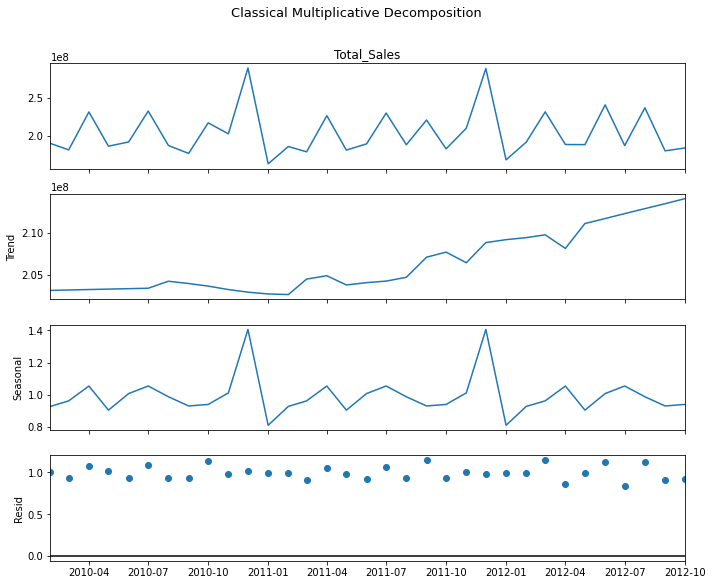

Monthly seasonal indices (1.0 = average month):

Month
1    0.811
2    0.928
3    0.962
4    1.055
5    0.905
6    1.008
7    1.055
8    0.988
9    0.931
10   0.940
11   1.012
12   1.407
Name: seasonal, dtype: float64


In [4]:
decomp = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Classical Multiplicative Decomposition', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

seasonal_idx = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
print("Monthly seasonal indices (1.0 = average month):\n")
print(seasonal_idx.round(3))

## 4. Stationarity: ADF & KPSS Tests

- **ADF** - H0: series has a unit root (non-stationary)
- **KPSS** - H0: series is (trend-)stationary

Using both guards against relying on a single test's assumptions.


In [5]:
def adf_report(series, label):
    result = adfuller(series, autolag='AIC')
    print(f"--- ADF: {label} ---")
    print(f"statistic={result[0]:.4f}  p-value={result[1]:.4f}  lags={result[2]}")
    print(f"conclusion: {'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'}\n")

def kpss_report(series, label):
    result = kpss(series, regression='c', nlags='auto')
    print(f"--- KPSS: {label} ---")
    print(f"statistic={result[0]:.4f}  p-value={result[1]:.4f}")
    print(f"conclusion: {'NON-STATIONARY' if result[1] < 0.05 else 'STATIONARY'}\n")

ts_diff = ts.diff().dropna()

adf_report(ts, "level"); kpss_report(ts, "level")
adf_report(ts_diff, "1st difference"); kpss_report(ts_diff, "1st difference")


--- ADF: level ---
statistic=-6.1645  p-value=0.0000  lags=1
conclusion: STATIONARY

--- KPSS: level ---
statistic=0.5000  p-value=0.0417
conclusion: NON-STATIONARY

--- ADF: 1st difference ---
statistic=-3.2104  p-value=0.0194  lags=10
conclusion: STATIONARY

--- KPSS: 1st difference ---
statistic=0.2600  p-value=0.1000
conclusion: STATIONARY



**Interpretation:** at the level, ADF and KPSS give different results for the original data, likely because of the trend and strong seasonal pattern. After taking **ne regular difference**, both tests agree that the series is stationary, meaning its pattern becomes stable over time.

➡️ **d = 1** is adopted for the ARIMA models below.


## 5. ACF / PACF of the Differenced Series

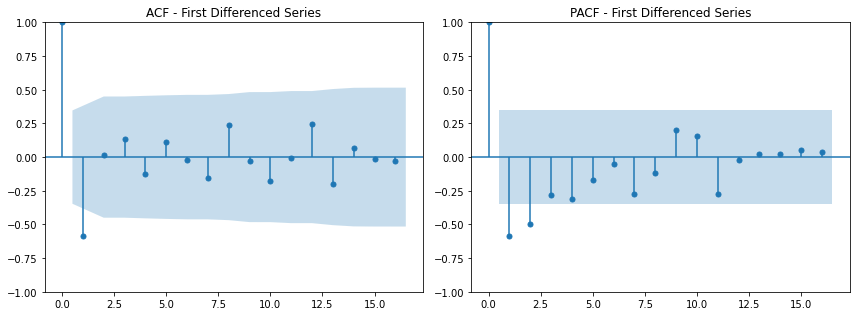

95% significance bound: +/-0.346


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_acf(ts_diff, ax=axes[0], lags=16, title='ACF - First Differenced Series')
plot_pacf(ts_diff, ax=axes[1], lags=16, method='ywm', title='PACF - First Differenced Series')
plt.tight_layout() 
plt.show()

ci = 1.96 / np.sqrt(len(ts_diff))
print(f"95% significance bound: +/-{ci:.3f}")

- **ACF**: The ACF shows one strong negative spike at lag 1, while the other lags stay within the confidence range. This suggests the data may have an MA(1) pattern.
- **PACF**: There are strong negative correlations at lags 1 and 2, which gradually decrease. This suggests the data may follow an AR(1) or AR(2) pattern, meaning recent values influence the next few values.

Since the pattern is not clear enough to choose one ARIMA model directly, several ARIMA(p,1,q) models are tested and compared using AIC and BIC. The best-performing model is selected based on these results.


## 6. Candidate ARIMA(p, d, q) Models - Grid Search & Comparison

In [7]:
results = []
fitted = {}
for p in range(3):
    for q in range(3):
        if p == 0 and q == 0:
            continue
        fit = ARIMA(ts, order=(p, 1, q)).fit()
        results.append({'p': p, 'd': 1, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic, 'LogLik': fit.llf})
        fitted[(p, 1, q)] = fit

grid_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
grid_df


,p,d,q,AIC,BIC,LogLik
0,0,1,1,"1,218.097","1,221.029",-607.049
1,1,1,0,"1,220.142","1,223.073",-608.071
2,1,1,1,"1,220.337","1,224.734",-607.169
3,0,1,2,"1,220.605","1,225.002",-607.302
4,2,1,0,"1,222.717","1,227.114",-608.358
5,2,1,1,"1,222.935","1,228.798",-607.468
6,1,1,2,"1,223.348","1,229.211",-607.674
7,2,1,2,"1,226.096","1,233.425",-608.048


In [8]:
best_order = tuple(grid_df.iloc[0][['p', 'd', 'q']].astype(int))
best_model = fitted[best_order]
print(f"Best model by AIC & BIC: ARIMA{best_order}")
print(best_model.summary())

Best model by AIC & BIC: ARIMA(0, 1, 1)
                               SARIMAX Results                                
Dep. Variable:            Total_Sales   No. Observations:                   33
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -607.049
Date:                Wed, 09 Sep 2026   AIC                           1218.097
Time:                        05:45:45   BIC                           1221.029
Sample:                    02-01-2010   HQIC                          1219.069
                         - 10-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7610      0.107     -7.093      0.000      -0.971      -0.551
sigma2       1.31e+15   1.47e-17   8.92e+31      0.000    1.31e+15    1.31e+15
Ljung-Box (L

Both AIC and BIC select ARIMA(0,1,1) as the best model. This also matches the MA(1) pattern seen in the ACF and PACF plots.

## 7. Residual Diagnostics

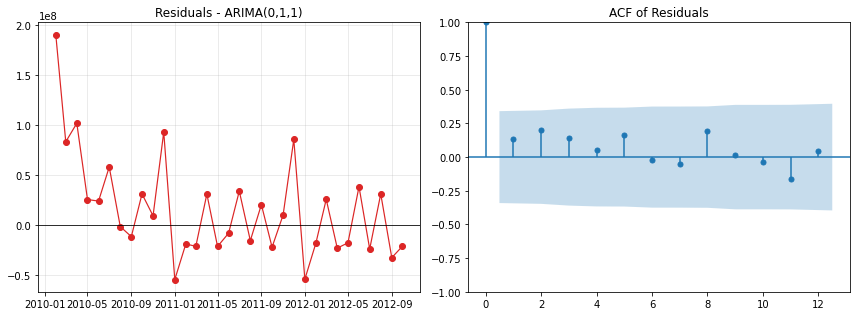

,lb_stat,lb_pvalue
6,4.042,0.671
12,7.490,0.824


In [9]:
resid = best_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(resid.index, resid.values, marker='o', color='#dc2626', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals - ARIMA(0,1,1)'); axes[0].grid(alpha=0.3)
plot_acf(resid, ax=axes[1], lags=12, title='ACF of Residuals')
plt.tight_layout() 
plt.show()

lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
lb

**Model adequacy:** The residual plot show no clear pattern or trend, and the ACF shows no significant spikes. The Ljung-Box test also confirms there is no significant autocorrelation at lag 6 or 12 (p > 0.6). Since **ARIMA(0,1,1)** has the lowest AIC/BIC among the 8 models tested, it is considered a good and adequate model.  


## 8. Forecasting the Next 12 Months (95% CI)

Four approaches, matching parts 12(i)-12(ii) of the brief:

1. **ARIMA(0,1,1)** - no seasonal component, no decomposition (baseline)
2. **SARIMA(0,1,1)(1,0,0)[12]** - seasonality modelled directly, no manual decomposition
3. **ARIMA + classical decomposition** - deseasonalise >> ARIMA on the deseasonalised series >> re-seasonalise the forecast
4. **SARIMAX** - the SARIMA structure plus Temperature, Fuel_Price, CPI, Unemployment as exogenous regressors (their own future values are forecast first)

In [10]:
# Forecast the exogenous regressors 12 months ahead
future_idx = pd.date_range(monthly.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')
exog_future = pd.DataFrame(index=future_idx)

# Temperature: seasonal-naive (same calendar month, one year earlier)
temp = monthly['Temperature']
exog_future['Temperature'] = [
    temp[(temp.index.year == d.year - 1) & (temp.index.month == d.month)].values[0]
    if len(temp[(temp.index.year == d.year - 1) & (temp.index.month == d.month)]) > 0
    else temp[temp.index.month == d.month].mean()
    for d in future_idx
]

# Fuel_Price, CPI, Unemployment: linear trend extrapolation (last 12 months)
def linear_extrapolate(series, n_future=12, n_hist=12):
    y = series.values[-n_hist:]
    x = np.arange(len(y))
    coef = np.polyfit(x, y, 1)
    return np.polyval(coef, np.arange(len(y), len(y) + n_future))

exog_future['Fuel_Price'] = linear_extrapolate(monthly['Fuel_Price'])
exog_future['CPI'] = linear_extrapolate(monthly['CPI'])
exog_future['Unemployment'] = linear_extrapolate(monthly['Unemployment'])
exog_future = exog_future[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
exog_future.round(3)


,Temperature,Fuel_Price,CPI,Unemployment
2012-11-01,50.033,3.894,176.895,7.013
2012-12-01,40.547,3.930,177.161,6.950
2013-01-01,40.823,3.966,177.427,6.887
2013-02-01,42.495,4.002,177.694,6.824
2013-03-01,52.490,4.038,177.960,6.762
2013-04-01,59.859,4.074,178.226,6.699
2013-05-01,67.237,4.110,178.492,6.636
2013-06-01,75.621,4.146,178.758,6.573
2013-07-01,79.404,4.183,179.024,6.510
2013-08-01,78.747,4.219,179.290,6.447


In [11]:
exog_all = monthly[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
h = 12
forecasts = {}

# 1. ARIMA(0,1,1)
m1 = ARIMA(ts, order=(0, 1, 1)).fit()
f1 = m1.get_forecast(h); ci1 = f1.conf_int(alpha=0.05)
forecasts['ARIMA(0,1,1)'] = pd.DataFrame({'mean': f1.predicted_mean.values,
    'lower': ci1.iloc[:, 0].values, 'upper': ci1.iloc[:, 1].values}, index=future_idx)

# 2. SARIMA(0,1,1)(1,0,0)[12]
m2 = SARIMAX(ts, order=(0, 1, 1), seasonal_order=(1, 0, 0, 12),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
f2 = m2.get_forecast(h); ci2 = f2.conf_int(alpha=0.05)
forecasts['SARIMA(0,1,1)(1,0,0)[12]'] = pd.DataFrame({'mean': f2.predicted_mean.values,
    'lower': ci2.iloc[:, 0].values, 'upper': ci2.iloc[:, 1].values}, index=future_idx)

# 3. ARIMA + classical decomposition
seasonal_idx = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
deseason = ts / decomp.seasonal
m3 = ARIMA(deseason, order=(0, 1, 1)).fit()
f3 = m3.get_forecast(h); ci3 = f3.conf_int(alpha=0.05)
seasonal_future = np.array([seasonal_idx[m] for m in future_idx.month])
forecasts['ARIMA+Decomposition'] = pd.DataFrame({
    'mean': f3.predicted_mean.values * seasonal_future,
    'lower': ci3.iloc[:, 0].values * seasonal_future,
    'upper': ci3.iloc[:, 1].values * seasonal_future}, index=future_idx)

# 4. SARIMAX
m4 = SARIMAX(ts, exog=exog_all, order=(0, 1, 1), seasonal_order=(1, 0, 0, 12),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
f4 = m4.get_forecast(h, exog=exog_future); ci4 = f4.conf_int(alpha=0.05)
forecasts['SARIMAX'] = pd.DataFrame({'mean': f4.predicted_mean.values,
    'lower': ci4.iloc[:, 0].values, 'upper': ci4.iloc[:, 1].values}, index=future_idx)

pd.concat({k: v['mean'] / 1e6 for k, v in forecasts.items()}, axis=1).round(1)

,"ARIMA(0,1,1)","SARIMA(0,1,1)(1,0,0)[12]",ARIMA+Decomposition,SARIMAX
2012-11-01,200.300,208.100,201.300,179.300
2012-12-01,200.300,253.100,279.800,170.000
2013-01-01,200.300,184.200,161.200,161.200
2013-02-01,200.300,197.600,184.600,151.400
2013-03-01,200.300,220.400,191.400,140.900
2013-04-01,200.300,195.800,209.800,131.100
2013-05-01,200.300,195.700,180.000,121.200
2013-06-01,200.300,225.700,200.500,110.800
2013-07-01,200.300,195.000,209.800,101.300
2013-08-01,200.300,223.500,196.500,91.400


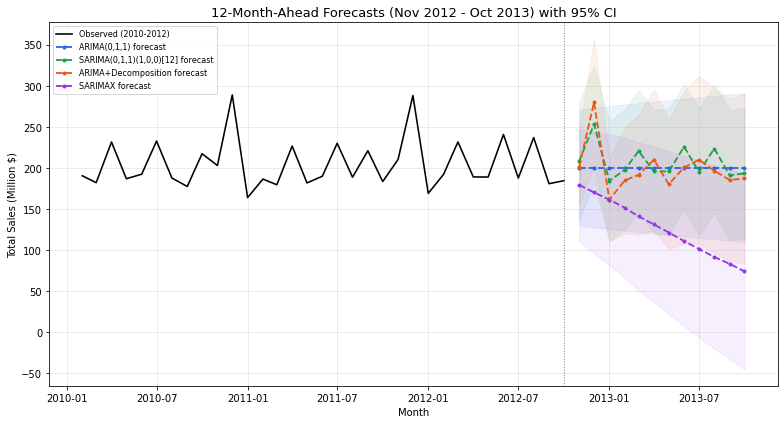

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(ts.index, ts.values / 1e6, color='black', linewidth=1.6, label='Observed (2010-2012)')
colors = {'ARIMA(0,1,1)': '#2563eb', 'SARIMA(0,1,1)(1,0,0)[12]': '#16a34a',
          'ARIMA+Decomposition': '#ea580c', 'SARIMAX': '#9333ea'}
for name, df in forecasts.items():
    ax.plot(df.index, df['mean'] / 1e6, color=colors[name], linewidth=1.8, linestyle='--',
            marker='o', markersize=3, label=f'{name} forecast')
    ax.fill_between(df.index, df['lower'] / 1e6, df['upper'] / 1e6, color=colors[name], alpha=0.08)
ax.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title('12-Month-Ahead Forecasts (Nov 2012 - Oct 2013) with 95% CI', fontsize=13)
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales (Million $)')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout() 
plt.show()


## 9. Backtest & Model Comparison

The last 6 months are kept aside for testing. Each model is trained on the first 27 months and then used to predict the last 6 months. The predictions are compared with the actual values using RMSE and MAE to see how well each model performs

In [13]:
def rmse(a, b): return float(np.sqrt(np.mean((np.array(a) - np.array(b)) ** 2)))
def mae(a, b): return float(np.mean(np.abs(np.array(a) - np.array(b))))

h_bt = 6
train_ts, test_ts = ts.iloc[:-h_bt], ts.iloc[-h_bt:]
train_exog, test_exog = exog_all.iloc[:-h_bt], exog_all.iloc[-h_bt:]
scores = {}

bt1 = ARIMA(train_ts, order=(0, 1, 1)).fit()
p1 = bt1.get_forecast(h_bt).predicted_mean
scores['ARIMA(0,1,1)'] = {'RMSE': rmse(test_ts, p1), 'MAE': mae(test_ts, p1), 'AIC': bt1.aic, 'BIC': bt1.bic}

bt2 = SARIMAX(train_ts, order=(0, 1, 1), seasonal_order=(1, 0, 0, 12),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
p2 = bt2.get_forecast(h_bt).predicted_mean
scores['SARIMA(0,1,1)(1,0,0)[12]'] = {'RMSE': rmse(test_ts, p2), 'MAE': mae(test_ts, p2), 'AIC': bt2.aic, 'BIC': bt2.bic}

decomp_train = seasonal_decompose(train_ts, model='multiplicative', period=12, extrapolate_trend='freq')
seas_idx_train = decomp_train.seasonal.groupby(decomp_train.seasonal.index.month).mean()
bt3 = ARIMA(train_ts / decomp_train.seasonal, order=(0, 1, 1)).fit()
p3 = bt3.get_forecast(h_bt).predicted_mean.values * np.array([seas_idx_train[m] for m in test_ts.index.month])
scores['ARIMA+Decomposition'] = {'RMSE': rmse(test_ts, p3), 'MAE': mae(test_ts, p3), 'AIC': bt3.aic, 'BIC': bt3.bic}

bt4 = SARIMAX(train_ts, exog=train_exog, order=(0, 1, 1), seasonal_order=(1, 0, 0, 12),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
p4 = bt4.get_forecast(h_bt, exog=test_exog).predicted_mean
scores['SARIMAX'] = {'RMSE': rmse(test_ts, p4), 'MAE': mae(test_ts, p4), 'AIC': bt4.aic, 'BIC': bt4.bic}

score_df = pd.DataFrame(scores).T
score_df.index.name = 'Model'
score_df.round(2)


,RMSE,MAE,AIC,BIC
Model,,,,
"ARIMA(0,1,1)","25,422,417.150","24,455,409.380",993.650,996.160
"SARIMA(0,1,1)(1,0,0)[12]","31,403,219.440","26,008,992.010",528.340,530.260
ARIMA+Decomposition,"38,704,581.290","28,861,630.610",959.560,962.080
SARIMAX,"66,438,790.760","57,852,309.180",534.520,538.990


### Why SARIMAX underperforms here

SARIMAX performed the worst when tested on new data, even though it used real information like inflation, unemployment, fuel prices, and weather.

There are two main reasons:

1. **Severe multicollinearity**: CPI and unemployment have a very strong relationship (-0.98), while fuel price and CPI are also strongly related (0.83). Since there are only 27 months of training data, the model struggles to understand the separate effect of each variable. This causes it to overestimate the future trend.
2. **Parameter-to-observation ratio**: The model estimates around 7 parameters using only 27 data points. This makes the model more likely to overfit the training data and perform poorly on new data.

**Recommendation:** The simpler **ARIMA(0,1,1)** model performs best on the test data, so it is the best choice for general forecasting. However, SARIMA or **ARIMA + Decomposition** would be better if capturing the December seasonal spike is more important than getting the lowest RMSE. SARIMAX may perform better with more historical data or fewer highly correlated variables.


In [14]:
print(monthly[['Temperature','Fuel_Price','CPI','Unemployment']].corr().round(2))

              Temperature  Fuel_Price    CPI  Unemployment
Temperature         1.000       0.210  0.160        -0.170
Fuel_Price          0.210       1.000  0.830        -0.750
CPI                 0.160       0.830  1.000        -0.980
Unemployment       -0.170      -0.750 -0.980         1.000


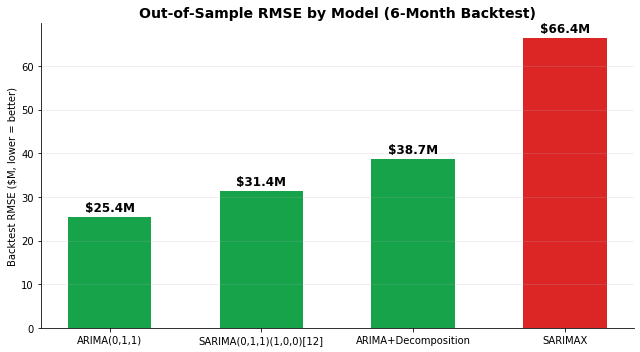

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#16a34a' if m != 'SARIMAX' else '#dc2626' for m in score_df.index]
bars = ax.bar(score_df.index, score_df['RMSE'] / 1e6, color=colors, width=0.55)
for b, v in zip(bars, score_df['RMSE'] / 1e6):
    ax.text(b.get_x() + b.get_width()/2, v + 1.2, f'${v:.1f}M', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Out-of-Sample RMSE by Model (6-Month Backtest)', fontsize=14, fontweight='bold')
ax.set_ylabel('Backtest RMSE ($M, lower = better)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Conclusion

- The data shows a small upward trend with a strong and consistent yearly seasonal pattern. Sales increase by around 41% in December and fall by around 19% in January. There are no major unusual shocks. 
- Applying one level of differencing **(d = 1)** makes the series stationary, confirmed by both the ADF and KPSS tests.
- **ARIMA(0,1,1)** is the best non-seasonal model based on both AIC and BIC. Its residuals behave like random noise, with Ljung-Box p-values above 0.6, showing that the model fits the data well.
- For 12-month forecasting, **SARIMA** and **ARIMA + Decomposition** perform better at capturing the December spike. Plain **ARIMA(0,1,1)** tends to produce a flatter forecast, which is expected for this type of model. SARIMAX performs worse because the dataset is small and the input variables are highly correlated.
- **Overall recommendation:** Use **SARIMA or Decomposition + ARIMA** when capturing seasonal patterns like the December spike is important. **ARIMA(0,1,1)** can be used as a simpler and more stable backup model.